# Multi-Asset Conditional Neural Process — Vol Surface Reconstruction

Each **market day** provides a sparse, unordered set of quotes
$(k_i,\, T_i,\, u_i,\, \sigma_i)$ across 5 assets.
The model compresses this set into a structured latent code and decodes
predicted implied vols at **any** $(k, T, u)$ query — no fixed grid required.

The data-generating process is **fully stochastic**: Heston parameters
$(v_0, \kappa, \theta, \xi, \rho)$ follow independent OU processes per asset,
so each training day has genuinely different vol surface shapes.

### Architecture

```
context set {(k_i, T_i, u_i, σ_i)}  ←  variable size, all assets mixed
             │
   AssetEmbedding(u_i) → concat with (k_i, T_i, σ_i)
             │
   Linear → d_model
             │
   ObsTransformer × L_obs          ←  cross-obs attention (all assets see each other)
             │
   Per-asset mean pool              ←  (B, 5, d_model)  — learned prior for empty slots
             │
   CrossAssetTransformer × L_cross  ←  assets exchange information
             │
   Linear → (B, 5, d_latent)  =  z = [z_0 | z_1 | z_2 | z_3 | z_4]

   Decoder:  z_u concat (k*, T*)  →  MLP  →  σ̂(k*, T*, u*)
```

**Key properties**
- Permutation invariant in observations (set encoder)
- Joint encoding: each z_u contains both idiosyncratic and market-wide information
- Decoder is asset-agnostic: asset identity enters only through which z_u is used
- Enables latent-space experiments: fix 4 assets, move 1

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import matplotlib.pyplot as plt
import time, warnings
warnings.filterwarnings('ignore')

print(f"PyTorch {torch.__version__}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
torch.manual_seed(0)
np.random.seed(0)

PyTorch 2.6.0+cu124
Device: cuda


In [38]:
# ── Hyperparameters ──────────────────────────────────────────────────────────

N_ASSETS = 5
ASSET_NAMES = [f'asset_{i}' for i in range(N_ASSETS)]

# Model
D_ASSET        = 16   # Asset id encoding dimension.
D_MODEL        = 64  # Asset + features encoding dimension.
N_HEADS_OBS    = 8
N_LAYERS_OBS   = 4
N_HEADS_CROSS  = 8
N_LAYERS_CROSS = 8
D_LATENT       = 32    # per-asset latent dim (total = D_LATENT * N_ASSETS)
D_HIDDEN       = 256
N_HIDDEN_DEC   = 5
DROPOUT        = 0.05

# Training — context range applies *across all assets* jointly
N_EPOCHS   = 2000
BATCH_SIZE = 64
LR         = 3e-4
CTX_MIN    = 3    # min total context observations
CTX_MAX    = 400  # max total context observations (= ctx pool size)

# Data layout — must match notebook 01 generation
N_CTX_POOL = CTX_MAX                    # first N_CTX_POOL points are context candidates
N_TGT_POOL = CTX_MAX                    # last  N_TGT_POOL points are target candidates
N_TOTAL    = N_CTX_POOL + N_TGT_POOL   # 800 points per day

print(f"Latent space: R^({N_ASSETS}×{D_LATENT}) = R^{N_ASSETS*D_LATENT}")
print(f"Context range [{CTX_MIN}, {CTX_MAX}]  |  Points per day: {N_TOTAL}")

Latent space: R^(5×32) = R^160
Context range [3, 400]  |  Points per day: 800


In [39]:
# ── Load data ────────────────────────────────────────────────────────────────
data = np.load('../Data/heston_multiasset_training.npz')

lm_all  = data['lm']        # (N_DAYS, N_TOTAL)
T_all   = data['maturity']  # (N_DAYS, N_TOTAL)
aid_all = data['asset_id']  # (N_DAYS, N_TOTAL)  int8
iv_all  = data['iv']        # (N_DAYS, N_TOTAL)
split   = data['split']     # (N_DAYS,)
params  = data['params']    # (N_DAYS, N_ASSETS, 5) = [v0, kappa, theta, xi, rho]

# Load fully stochastic parameter paths (shape: N_DAYS x N_ASSETS each)
theta_path = data['theta_path'] if 'theta_path' in data else None  # (N_DAYS, 5)
kappa_path = data['kappa_path'] if 'kappa_path' in data else None  # (N_DAYS, 5)
xi_path    = data['xi_path']    if 'xi_path'    in data else None  # (N_DAYS, 5)
rho_path   = data['rho_path']   if 'rho_path'   in data else None  # (N_DAYS, 5)

N_DAYS = lm_all.shape[0]
assert N_TOTAL == lm_all.shape[1], f"N_TOTAL mismatch: expected {N_TOTAL}, got {lm_all.shape[1]}"

# Stack into feat (N_DAYS, N_TOTAL, 3) = [lm, T, IV]
feat_raw = np.stack([lm_all, T_all, iv_all], axis=-1).astype(np.float32)
aids_raw = aid_all.astype(np.int64)   # (N_DAYS, N_TOTAL)

train_idx = np.where(split == 0)[0]
val_idx   = np.where(split == 1)[0]

print(f"Days: {N_DAYS}  ({(split==0).sum()} train / {(split==1).sum()} val)")
print(f"Points/day: {N_TOTAL}  (ctx pool 0:{N_CTX_POOL}, tgt pool {N_CTX_POOL}:{N_TOTAL})")
print(f"feat_raw: {feat_raw.shape}  aids: {aids_raw.shape}")
print(f"params:   {params.shape}  — [v0, kappa, theta, xi, rho] per asset per day")
if theta_path is not None:
    print(f"theta_path: {theta_path.shape}, kappa_path: {kappa_path.shape}")
    print(f"xi_path: {xi_path.shape},    rho_path: {rho_path.shape}")

Days: 5000  (4500 train / 500 val)
Points/day: 800  (ctx pool 0:400, tgt pool 400:800)
feat_raw: (5000, 800, 3)  aids: (5000, 800)
params:   (5000, 5, 5)  — [v0, kappa, theta, xi, rho] per asset per day
theta_path: (5000, 5), kappa_path: (5000, 5)
xi_path: (5000, 5),    rho_path: (5000, 5)


In [40]:
# ── Normalisation (fit on train only) ────────────────────────────────────────
train_flat = feat_raw[train_idx].reshape(-1, 3)

norm_mean = train_flat.mean(0)
norm_std  = train_flat.std(0) + 1e-8

def normalise(x):    return (x - norm_mean) / norm_std
def denorm_iv(iv_n): return iv_n * norm_std[2] + norm_mean[2]

feat_norm = normalise(feat_raw)

feat_t = torch.from_numpy(feat_norm.astype(np.float32)).to(device)
aids_t = torch.from_numpy(aids_raw.astype(np.int64)).to(device)

feat_train = feat_t[train_idx]
aids_train = aids_t[train_idx]
feat_val   = feat_t[val_idx]
aids_val   = aids_t[val_idx]

print(f"Normalisation — lm: μ={norm_mean[0]:.3f} σ={norm_std[0]:.3f}")
print(f"              mat: μ={norm_mean[1]:.3f} σ={norm_std[1]:.3f}")
print(f"               IV: μ={norm_mean[2]:.3f} σ={norm_std[2]:.3f}")
print(f"Train: {feat_train.shape}  Val: {feat_val.shape}")

# ── Visualisation grid (for eval / interpolation plots) ──────────────────────
VIS_LM       = np.linspace(-0.40, 0.40, 20).astype(np.float32)
VIS_MATS     = np.array([0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0], dtype=np.float32)
N_VIS_LM     = len(VIS_LM)
N_VIS_MATS   = len(VIS_MATS)
N_VIS_GRID   = N_VIS_LM * N_VIS_MATS   # 160

VIS_GRID_RAW = np.array([(lm, T) for T in VIS_MATS for lm in VIS_LM], dtype=np.float32)

# Normalised vis grid ready for decoder queries: (1, N_VIS_GRID, 2)
_vis_pad = normalise(np.column_stack([VIS_GRID_RAW, np.zeros(N_VIS_GRID)]))[:, :2].astype(np.float32)
vis_grid_t = torch.from_numpy(_vis_pad).to(device).unsqueeze(0)

print(f"Vis grid: {N_VIS_LM} lm × {N_VIS_MATS} T = {N_VIS_GRID} pts")

Normalisation — lm: μ=0.000 σ=0.240
              mat: μ=0.874 σ=0.480
               IV: μ=0.222 σ=0.070
Train: torch.Size([4500, 800, 3])  Val: torch.Size([500, 800, 3])
Vis grid: 20 lm × 8 T = 160 pts


In [41]:
# ── Model ────────────────────────────────────────────────────────────────────

class MultiAssetEncoder(nn.Module):
    """
    Two-stage encoder:
      1. ObsTransformer — all observations (from all assets) attend to each other.
      2. Per-asset mean pool → cross-asset transformer → per-asset latent codes.

    Asset identity enters via a learned embedding concatenated to each observation.
    Assets with zero context observations are initialised from a learned prior and
    updated by the cross-asset transformer based on their neighbours.
    """
    def __init__(self, n_assets, d_asset, d_model,
                 n_heads_obs, n_layers_obs, n_heads_cross, n_layers_cross,
                 d_latent, dropout):
        super().__init__()
        self.n_assets   = n_assets
        self.asset_embed = nn.Embedding(n_assets, d_asset)

        self.obs_proj = nn.Linear(d_asset + 3, d_model)
        obs_layer = nn.TransformerEncoderLayer(
            d_model, n_heads_obs, dim_feedforward=d_model*4,
            dropout=dropout, batch_first=True, norm_first=True)
        self.obs_enc  = nn.TransformerEncoder(obs_layer, n_layers_obs)
        self.obs_norm = nn.LayerNorm(d_model)

        # Learned prior for each asset slot (used when no context for that asset)
        self.prior = nn.Parameter(torch.zeros(n_assets, d_model))

        cross_layer = nn.TransformerEncoderLayer(
            d_model, n_heads_cross, dim_feedforward=d_model*4,
            dropout=dropout, batch_first=True, norm_first=True)
        self.cross_enc  = nn.TransformerEncoder(cross_layer, n_layers_cross)
        self.cross_norm = nn.LayerNorm(d_model)

        self.to_latent = nn.Linear(d_model, d_latent)

    def forward(self, obs_feat, obs_aid):
        """
        B is batch size, n_ctx amount of context.
        obs_feat : (B, n_ctx, 3)   normalised [lm, T, IV]
        obs_aid  : (B, n_ctx) long  asset IDs 0..N_ASSETS-1
        returns  : (B, N_ASSETS, d_latent)
        """
        B = obs_feat.shape[0]

        # 1. Embed asset IDs, project to d_model
        e = self.asset_embed(obs_aid)                          # (B, n_ctx, d_asset)
        h = self.obs_proj(torch.cat([e, obs_feat], dim=-1))    # (B, n_ctx, d_model)

        # 2. Cross-observation transformer (all assets see each other)
        h = self.obs_enc(h)
        h = self.obs_norm(h)                                   # (B, n_ctx, d_model)

        # 3. Per-asset mean pool (vectorised via one-hot)
        one_hot = F.one_hot(obs_aid, self.n_assets).float()    # (B, n_ctx, N_ASSETS)
        sums    = torch.einsum('bcp,bcd->bpd', one_hot, h)     # (B, N_ASSETS, d_model)
        counts  = one_hot.sum(1)                               # (B, N_ASSETS)
        means   = sums / counts.unsqueeze(-1).clamp(min=1)
        has_data = counts.gt(0).unsqueeze(-1)                  # (B, N_ASSETS, 1)
        prior_exp = self.prior.unsqueeze(0).expand(B, -1, -1)
        slots = torch.where(has_data, means, prior_exp)        # (B, N_ASSETS, d_model)

        # 4. Cross-asset transformer
        slots = self.cross_enc(slots)
        slots = self.cross_norm(slots)                         # (B, N_ASSETS, d_model)

        return self.to_latent(slots)                           # (B, N_ASSETS, d_latent)


class PointDecoder(nn.Module):
    """
    f(z_u, k, T) → σ̂.  Asset identity enters only through which z_u is passed.
    """
    def __init__(self, d_latent, d_hidden, n_hidden, dropout):
        super().__init__()
        layers = [nn.Linear(d_latent + 2, d_hidden), nn.GELU()]
        for _ in range(n_hidden - 1):
            layers += [nn.Dropout(dropout), nn.Linear(d_hidden, d_hidden), nn.GELU()]
        layers += [nn.Linear(d_hidden, 1)]
        self.mlp = nn.Sequential(*layers)

    def forward(self, z, qry_feat, qry_aid):
        """
        z        : (B, N_ASSETS, d_latent)
        qry_feat : (B, Q, 2)   normalised [lm, T]
        qry_aid  : (B, Q) long
        returns  : (B, Q)
        """
        B, Q = qry_aid.shape
        z_q = z[torch.arange(B, device=z.device).unsqueeze(1), qry_aid]  # (B, Q, d_latent)
        return self.mlp(torch.cat([z_q, qry_feat], dim=-1)).squeeze(-1)   # (B, Q)


class MultiAssetCNP(nn.Module):
    def __init__(self, n_assets, d_asset, d_model,
                 n_heads_obs, n_layers_obs, n_heads_cross, n_layers_cross,
                 d_latent, d_hidden, n_hidden_dec, dropout):
        super().__init__()
        self.encoder = MultiAssetEncoder(
            n_assets, d_asset, d_model,
            n_heads_obs, n_layers_obs, n_heads_cross, n_layers_cross,
            d_latent, dropout)
        self.decoder = PointDecoder(d_latent, d_hidden, n_hidden_dec, dropout)

    def encode(self, obs_feat, obs_aid):
        return self.encoder(obs_feat, obs_aid)          # (B, N_ASSETS, d_latent)

    def decode(self, z, qry_feat, qry_aid):
        return self.decoder(z, qry_feat, qry_aid)       # (B, Q)

    def forward(self, obs_feat, obs_aid, qry_feat, qry_aid):
        return self.decode(self.encode(obs_feat, obs_aid), qry_feat, qry_aid)


model = MultiAssetCNP(
    N_ASSETS, D_ASSET, D_MODEL,
    N_HEADS_OBS, N_LAYERS_OBS, N_HEADS_CROSS, N_LAYERS_CROSS,
    D_LATENT, D_HIDDEN, N_HIDDEN_DEC, DROPOUT,
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")

Trainable parameters: 876,209


In [43]:
# ── Training utilities ───────────────────────────────────────────────────────

def make_batch(feat, aids, day_idx, n_ctx):
    """
    feat     : (N, N_TOTAL, 3) normalised  [lm, T, IV]
    aids     : (N, N_TOTAL) long
    day_idx  : 1-D long tensor, length B
    n_ctx    : int in [CTX_MIN, CTX_MAX]

    Layout: feat[:, :N_CTX_POOL] = context candidates,
            feat[:, N_CTX_POOL:] = target candidates.
    Randomly selects n_ctx from the context pool; predicts all N_TOTAL points.

    Returns
    -------
    obs_feat : (B, n_ctx, 3)
    obs_aid  : (B, n_ctx)
    qry_feat : (B, N_TOTAL, 2)
    qry_aid  : (B, N_TOTAL)
    target   : (B, N_TOTAL)
    """
    B = len(day_idx)
    f = feat[day_idx]   # (B, N_TOTAL, 3)
    a = aids[day_idx]   # (B, N_TOTAL)

    # Draw n_ctx indices from context pool (first N_CTX_POOL points)
    perm    = torch.rand(B, N_CTX_POOL, device=feat.device).argsort(dim=1)
    ctx_idx = perm[:, :n_ctx]
    obs_feat = f[:, :N_CTX_POOL].gather(1, ctx_idx.unsqueeze(-1).expand(-1, -1, 3))
    obs_aid  = a[:, :N_CTX_POOL].gather(1, ctx_idx)

    qry_feat = f[:, :, :2]   # (B, N_TOTAL, 2)
    qry_aid  = a
    target   = f[:, :, 2]    # (B, N_TOTAL)

    return obs_feat, obs_aid, qry_feat, qry_aid, target


@torch.no_grad()
def eval_rmse(model, feat, aids, n_ctx, n_samples=8):
    """Average RMSE on the target pool over n_samples random context draws."""
    model.eval()
    B = len(feat)
    rmse_sum = 0.0
    for _ in range(n_samples):
        nc = n_ctx
        of, oa, qf, qa, tgt = make_batch(feat, aids, torch.arange(B, device=device), nc)
        pred     = model(of, oa, qf, qa)
        pred_tgt = pred[:, N_CTX_POOL:]
        tgt_tgt  = tgt[:, N_CTX_POOL:]
        rmse_sum += F.mse_loss(pred_tgt, tgt_tgt).sqrt().item()
    return rmse_sum / n_samples


def encode_days(feat, aids, n_ctx=None, batch=64):
    """
    Returns (N_DAYS, N_ASSETS, d_latent) numpy array.
    Encodes from the context pool only (first N_CTX_POOL points).
    """
    if n_ctx is None:
        n_ctx = N_CTX_POOL
    n_ctx = min(n_ctx, N_CTX_POOL)
    model.eval()
    codes = []
    with torch.no_grad():
        for b in range(0, len(feat), batch):
            f_b = feat[b : b + batch]
            a_b = aids[b : b + batch]
            of  = f_b[:, :n_ctx]
            oa  = a_b[:, :n_ctx]
            codes.append(model.encode(of, oa).cpu().numpy())
    return np.concatenate(codes, 0)   # (N_DAYS, N_ASSETS, d_latent)

In [44]:
# ── Training loop ────────────────────────────────────────────────────────────
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=N_EPOCHS, eta_min=LR / 20)

train_rmse_hist, val_rmse_hist = [], []
LOG_EVERY = 10

t0 = time.time()
for epoch in range(1, N_EPOCHS + 1):
    model.train()
    perm      = torch.randperm(len(feat_train), device=device)
    epoch_mse = 0.0
    n_batches = 0

    for b in range(0, len(feat_train) - BATCH_SIZE + 1, BATCH_SIZE):
        idx   = perm[b : b + BATCH_SIZE]
        n_ctx = int(np.random.randint(CTX_MIN, CTX_MAX + 1))
        of, oa, qf, qa, tgt = make_batch(feat_train, aids_train, idx, n_ctx)

        pred = model(of, oa, qf, qa)
        loss = F.mse_loss(pred, tgt)

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        epoch_mse += loss.item()
        n_batches += 1

    scheduler.step()
    train_rmse_hist.append(np.sqrt(epoch_mse / max(n_batches, 1)))

    if epoch % LOG_EVERY == 0:
        vr = eval_rmse(model, feat_val, aids_val, n_ctx=30)
        val_rmse_hist.append((epoch, vr))
        elapsed = time.time() - t0
        print(f"Epoch {epoch:4d} | train RMSE {train_rmse_hist[-1]:.5f} | "
              f"val RMSE {vr:.5f} | {elapsed:.0f}s")

print("Training complete.")

Epoch   10 | train RMSE 0.15960 | val RMSE 0.14805 | 116s
Epoch   20 | train RMSE 0.14737 | val RMSE 0.14432 | 244s
Epoch   30 | train RMSE 0.13751 | val RMSE 0.11217 | 375s
Epoch   40 | train RMSE 0.11147 | val RMSE 0.09751 | 514s
Epoch   50 | train RMSE 0.10976 | val RMSE 0.10692 | 640s
Epoch   60 | train RMSE 0.07624 | val RMSE 0.08074 | 773s
Epoch   70 | train RMSE 0.07931 | val RMSE 0.07711 | 905s
Epoch   80 | train RMSE 0.06965 | val RMSE 0.07376 | 1020s
Epoch   90 | train RMSE 0.10877 | val RMSE 0.07716 | 1102s
Epoch  100 | train RMSE 0.07742 | val RMSE 0.06842 | 1183s
Epoch  110 | train RMSE 0.06641 | val RMSE 0.06530 | 1264s
Epoch  120 | train RMSE 0.10176 | val RMSE 0.08505 | 1346s
Epoch  130 | train RMSE 0.07762 | val RMSE 0.06303 | 1436s
Epoch  140 | train RMSE 0.08829 | val RMSE 0.07166 | 1550s
Epoch  150 | train RMSE 0.09175 | val RMSE 0.07020 | 1666s
Epoch  160 | train RMSE 0.08002 | val RMSE 0.07082 | 1780s
Epoch  170 | train RMSE 0.06041 | val RMSE 0.06097 | 1894s
Epoc

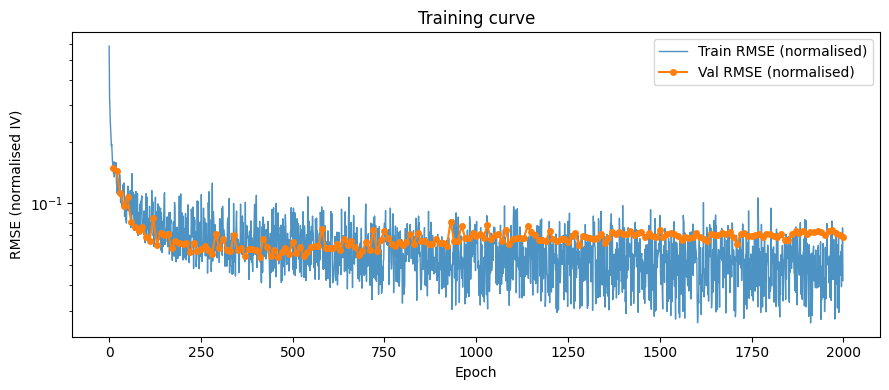

In [45]:
# ── Training curve ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(train_rmse_hist, lw=1, alpha=0.8, label='Train RMSE (normalised)')
if val_rmse_hist:
    vx, vy = zip(*val_rmse_hist)
    ax.plot(vx, vy, 'o-', color='C1', ms=4, label='Val RMSE (normalised)')
ax.set_xlabel('Epoch'); ax.set_ylabel('RMSE (normalised IV)')
ax.set_yscale('log'); ax.legend(); ax.set_title('Training curve')
plt.tight_layout(); plt.show()

## Reconstruction Quality

For each asset we show the true surface (dashed) vs predicted (solid) at several
context sizes.  The context is drawn randomly from **all 5 assets jointly** —
the model must use cross-asset information to sharpen its reconstructions.

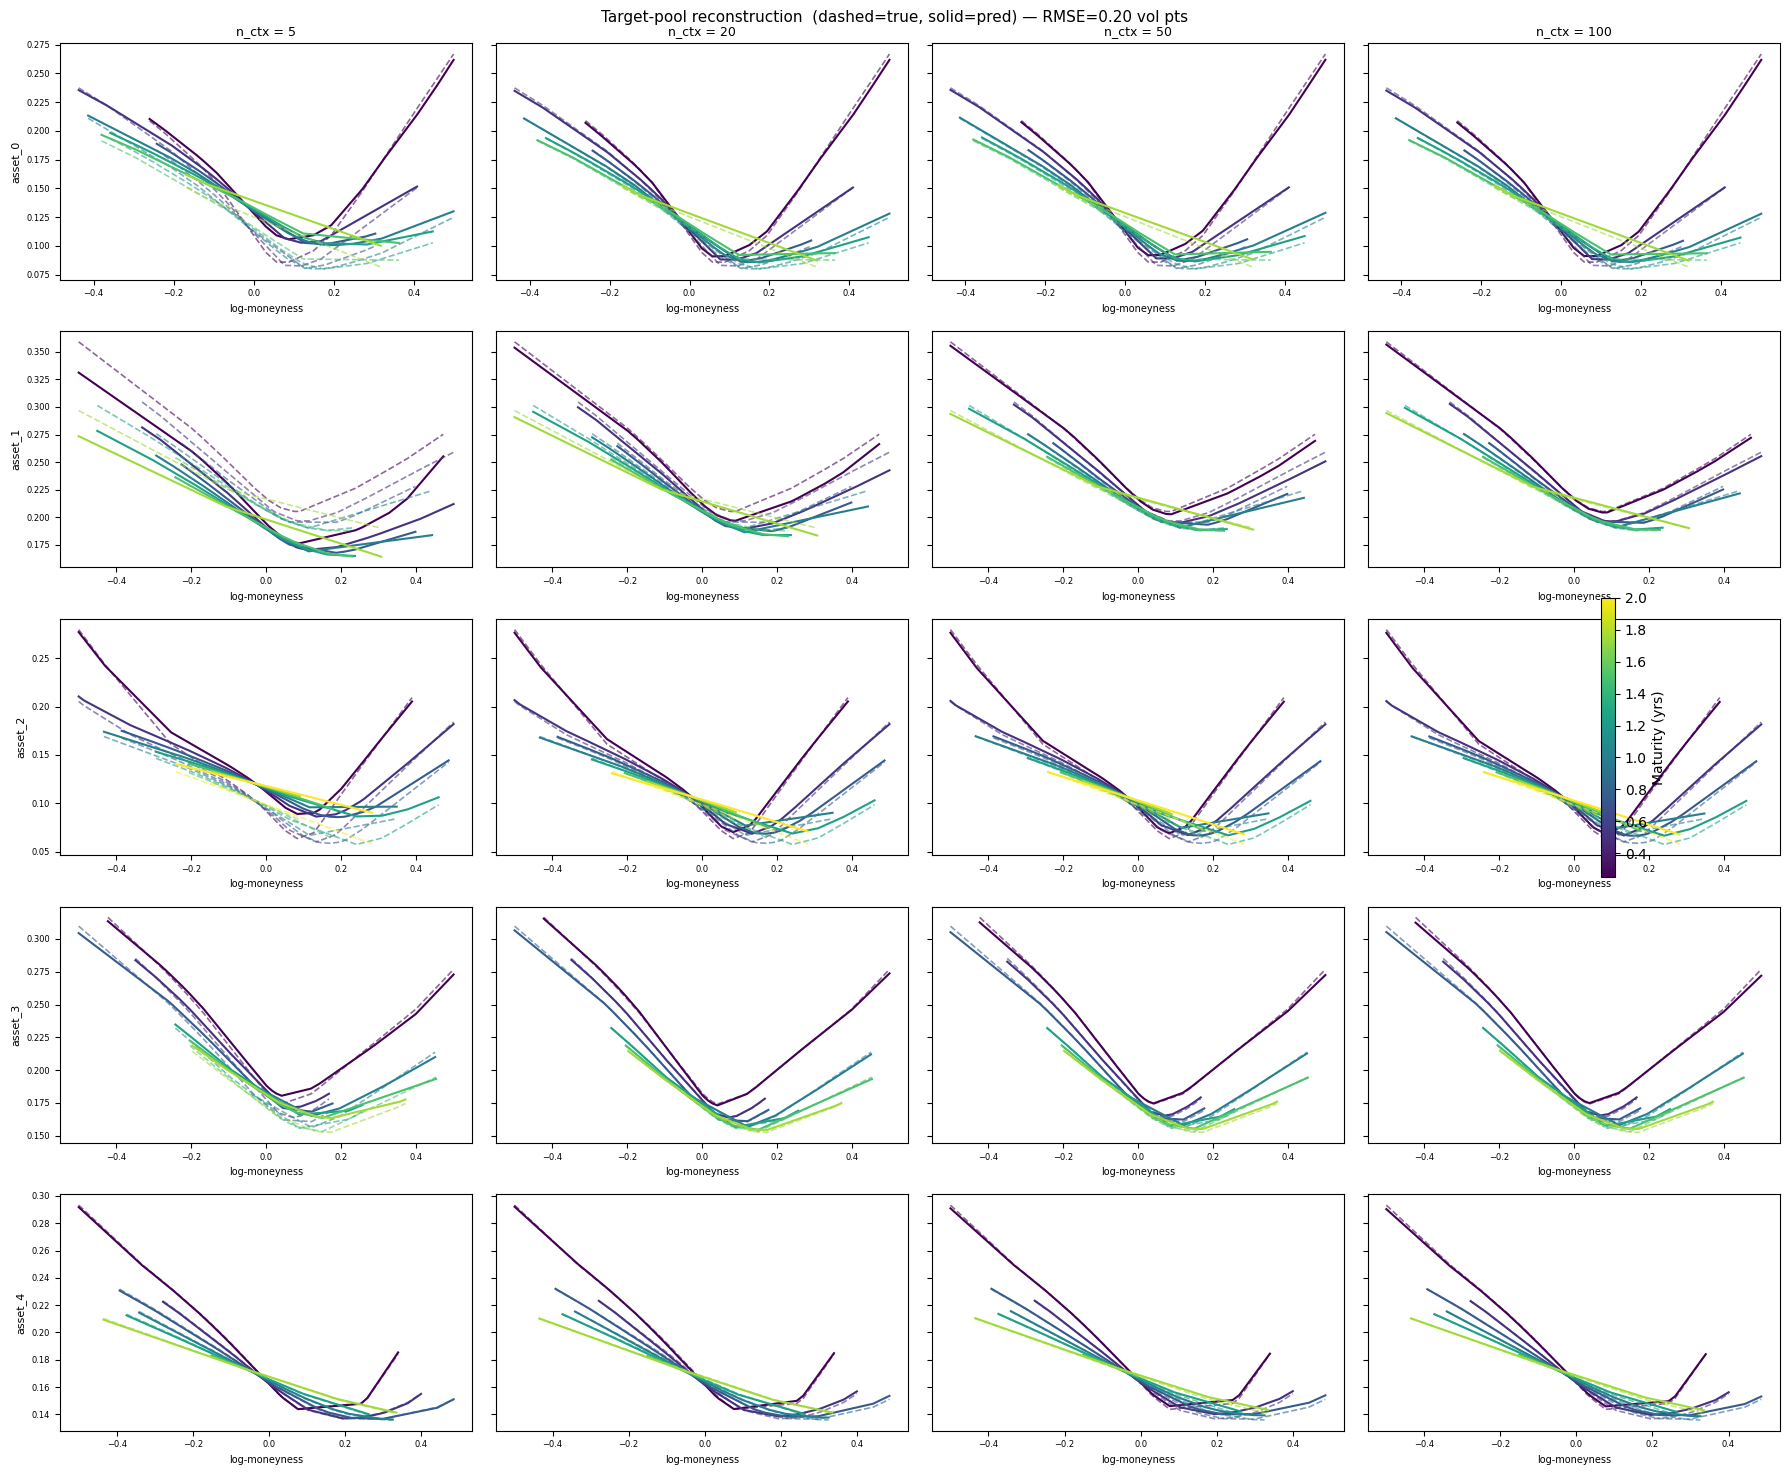

In [46]:
ctx_sizes = [5, 20, 50, 100]
N_EVALS   = 20

model.eval()
eval_days = torch.arange(min(5, len(feat_val)), device=device)

results = {}
with torch.no_grad():
    for nc in ctx_sizes:
        preds, trues = [], []
        for _ in range(N_EVALS):
            of, oa, qf, qa, tgt = make_batch(feat_val, aids_val, eval_days, nc)
            pred_n = model(of, oa, qf, qa)
            preds.append(denorm_iv(pred_n.cpu().numpy()))
            trues.append(denorm_iv(tgt.cpu().numpy()))
        results[nc] = {
            'pred': np.stack(preds).mean(0),   # (n_eval_days, N_TOTAL)
            'true': np.stack(trues).mean(0),
        }

# Plot target-pool points for the first val day
day0_lm  = lm_all[val_idx[0]]              # (N_TOTAL,) raw
day0_T   = T_all[val_idx[0]]               # (N_TOTAL,)
day0_aid = aid_all[val_idx[0]].astype(int)

tgt_mask = np.zeros(N_TOTAL, dtype=bool)
tgt_mask[N_CTX_POOL:] = True

mat_bins_unique = np.unique(day0_T)
cmap    = plt.cm.viridis
col_map = {T: cmap(i / max(len(mat_bins_unique)-1, 1))
           for i, T in enumerate(sorted(mat_bins_unique))}

fig, axes = plt.subplots(N_ASSETS, len(ctx_sizes),
                          figsize=(4.5*len(ctx_sizes), 3*N_ASSETS), sharey='row')

for ci, nc in enumerate(ctx_sizes):
    pred_d = results[nc]['pred'][0]
    true_d = results[nc]['true'][0]

    for a in range(N_ASSETS):
        ax  = axes[a, ci]
        a_m = (day0_aid == a) & tgt_mask
        for T_bin in sorted(mat_bins_unique):
            m = a_m & (day0_T == T_bin)
            if m.sum() < 2:
                continue
            order = np.argsort(day0_lm[m])
            ax.plot(day0_lm[m][order], true_d[m][order], '--',
                    color=col_map[T_bin], lw=1.2, alpha=0.6)
            ax.plot(day0_lm[m][order], pred_d[m][order], '-',
                    color=col_map[T_bin], lw=1.5)
        if a == 0:
            ax.set_title(f'n_ctx = {nc}', fontsize=9)
        if ci == 0:
            ax.set_ylabel(ASSET_NAMES[a], fontsize=8)
        ax.set_xlabel('log-moneyness', fontsize=7)
        ax.tick_params(labelsize=6)

rmse_tgt = np.sqrt(np.mean(
    (results[ctx_sizes[-1]]['pred'][:, N_CTX_POOL:]
   - results[ctx_sizes[-1]]['true'][:, N_CTX_POOL:])**2
))
fig.suptitle(
    f'Target-pool reconstruction  (dashed=true, solid=pred) — RMSE={rmse_tgt*100:.2f} vol pts',
    fontsize=11)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0.25, 2.0))
fig.colorbar(sm, ax=axes, label='Maturity (yrs)', fraction=0.01)
plt.tight_layout(); plt.show()

## Per-Maturity Error

Using a fixed context size of n_ctx=100, we split target-pool points into
maturity bins and compute RMSE (in vol points) for each bin separately.
This reveals whether the model struggles more at short or long maturities.

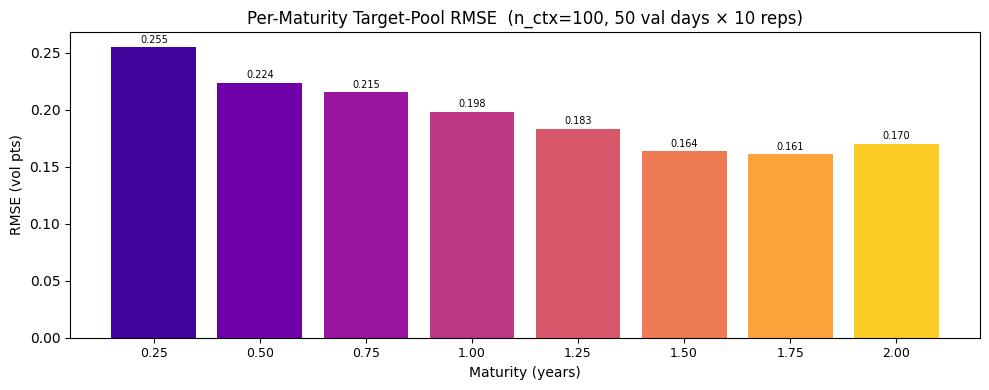

Per-maturity RMSE (vol pts):
  T=0.25: 0.2550
  T=0.50: 0.2236
  T=0.75: 0.2153
  T=1.00: 0.1983
  T=1.25: 0.1834
  T=1.50: 0.1638
  T=1.75: 0.1612
  T=2.00: 0.1702


In [47]:
# ── Per-maturity RMSE ────────────────────────────────────────────────────────
N_EVAL_DAYS_MAT = min(50, len(feat_val))
eval_days_mat   = torch.arange(N_EVAL_DAYS_MAT, device=device)
N_CTX_MAT       = 100
N_REPS_MAT      = 10

# Collect all target-pool predictions and true values across repetitions
preds_mat_list, trues_mat_list = [], []
model.eval()
with torch.no_grad():
    for _ in range(N_REPS_MAT):
        of, oa, qf, qa, tgt = make_batch(feat_val, aids_val, eval_days_mat, N_CTX_MAT)
        pred = model(of, oa, qf, qa)
        # Only target pool
        preds_mat_list.append(denorm_iv(pred[:, N_CTX_POOL:].cpu().numpy()))   # (B, N_TGT_POOL)
        trues_mat_list.append(denorm_iv(tgt[:, N_CTX_POOL:].cpu().numpy()))

preds_mat = np.concatenate(preds_mat_list, axis=0)   # (N_EVAL_DAYS_MAT*N_REPS_MAT, N_TGT_POOL)
trues_mat = np.concatenate(trues_mat_list, axis=0)

# Get maturities for target pool of validation days
# We use the first N_EVAL_DAYS_MAT val days, tiled N_REPS_MAT times
T_tgt_all = np.tile(
    T_all[val_idx[:N_EVAL_DAYS_MAT], N_CTX_POOL:],  # (N_EVAL_DAYS_MAT, N_TGT_POOL)
    (N_REPS_MAT, 1)
)  # (N_EVAL_DAYS_MAT*N_REPS_MAT, N_TGT_POOL)

# Flatten
preds_flat = preds_mat.ravel()
trues_flat = trues_mat.ravel()
T_flat     = T_tgt_all.ravel()

# Bin by maturity
unique_mats = np.unique(T_all[val_idx[0], N_CTX_POOL:])
if len(unique_mats) > 12:
    # Use quantile bins if too many unique values
    mat_bins  = np.quantile(T_flat, np.linspace(0, 1, 9))
    bin_labels = [f'{(mat_bins[i]+mat_bins[i+1])/2:.2f}' for i in range(len(mat_bins)-1)]
    bin_indices = np.digitize(T_flat, mat_bins[1:-1])
else:
    unique_mats_sorted = np.sort(unique_mats)
    bin_labels = [f'{m:.2f}' for m in unique_mats_sorted]
    # Map each point to its maturity index
    mat_to_idx = {m: i for i, m in enumerate(unique_mats_sorted)}
    bin_indices = np.array([mat_to_idx.get(t, 0) for t in T_flat])
    mat_bins = None

rmse_by_mat = []
for i in range(len(bin_labels)):
    mask = bin_indices == i
    if mask.sum() > 0:
        rmse_by_mat.append(np.sqrt(np.mean((preds_flat[mask] - trues_flat[mask])**2)) * 100)
    else:
        rmse_by_mat.append(np.nan)

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(bin_labels))
bars = ax.bar(x, rmse_by_mat, color=plt.cm.plasma(np.linspace(0.1, 0.9, len(bin_labels))))
ax.set_xticks(x)
ax.set_xticklabels(bin_labels, fontsize=9)
ax.set_xlabel('Maturity (years)')
ax.set_ylabel('RMSE (vol pts)')
ax.set_title(f'Per-Maturity Target-Pool RMSE  (n_ctx={N_CTX_MAT}, {N_EVAL_DAYS_MAT} val days × {N_REPS_MAT} reps)')
for bar, val in zip(bars, rmse_by_mat):
    if not np.isnan(val):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7)
plt.tight_layout(); plt.show()

print("Per-maturity RMSE (vol pts):")
for label, rmse in zip(bin_labels, rmse_by_mat):
    print(f"  T={label}: {rmse:.4f}")

## Context Concentration Test

We fix total context n_ctx=30 and compare three conditions:
- **uniform**: context sampled from all 5 assets randomly (existing behavior)
- **concentrated**: all 30 context points forced to come from asset 0 only
- **one-per-asset**: exactly 6 context points per asset (perfectly balanced)

For each condition, we compute target-pool RMSE per asset.
If the cross-asset transformer is working, the concentrated condition should
still produce reasonable predictions for assets 1–4 via information transfer.

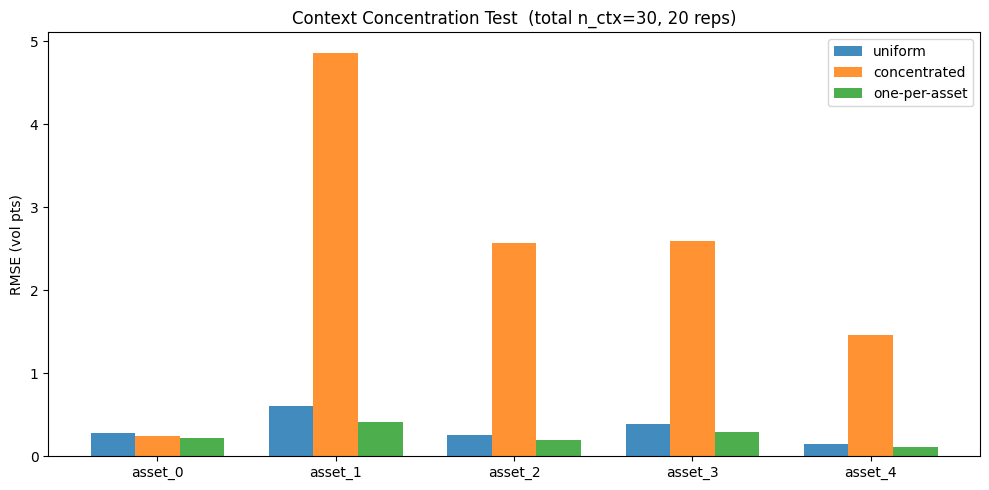


RMSE (vol pts) by condition and asset:
                   asset_0    asset_1    asset_2    asset_3    asset_4
uniform             0.2786     0.6094     0.2554     0.3897     0.1539
concentrated        0.2415     4.8643     2.5657     2.5986     1.4646
one-per-asset       0.2242     0.4099     0.1975     0.2984     0.1120


In [48]:
# ── Context concentration test ───────────────────────────────────────────────

def make_batch_asset_filtered(feat, aids, day_idx, n_ctx, filter_asset=None):
    """
    Like make_batch but context is drawn only from filter_asset
    (or all assets if filter_asset is None).
    """
    B = len(day_idx)
    f = feat[day_idx]
    a = aids[day_idx]
    ctx_f = f[:, :N_CTX_POOL]
    ctx_a = a[:, :N_CTX_POOL]
    if filter_asset is not None:
        obs_feat_list, obs_aid_list = [], []
        for b in range(B):
            mask = (ctx_a[b] == filter_asset).nonzero(as_tuple=False).squeeze(1)
            if len(mask) >= n_ctx:
                perm = mask[torch.randperm(len(mask), device=feat.device)[:n_ctx]]
            else:
                reps = (n_ctx // len(mask)) + 1
                perm = mask.repeat(reps)[:n_ctx]
            obs_feat_list.append(ctx_f[b][perm])
            obs_aid_list.append(ctx_a[b][perm])
        obs_feat = torch.stack(obs_feat_list)
        obs_aid  = torch.stack(obs_aid_list)
    else:
        perm    = torch.rand(B, N_CTX_POOL, device=feat.device).argsort(dim=1)
        ctx_idx = perm[:, :n_ctx]
        obs_feat = ctx_f.gather(1, ctx_idx.unsqueeze(-1).expand(-1, -1, 3))
        obs_aid  = ctx_a.gather(1, ctx_idx)
    qry_feat = f[:, :, :2]
    qry_aid  = a
    target   = f[:, :, 2]
    return obs_feat, obs_aid, qry_feat, qry_aid, target


def make_batch_balanced(feat, aids, day_idx, n_ctx_per_asset):
    """Exactly n_ctx_per_asset context points from each asset."""
    B = len(day_idx)
    f = feat[day_idx]
    a = aids[day_idx]
    ctx_f = f[:, :N_CTX_POOL]
    ctx_a = a[:, :N_CTX_POOL]
    obs_feat_list, obs_aid_list = [], []
    for b in range(B):
        per_asset_feats, per_asset_aids = [], []
        for asset in range(N_ASSETS):
            mask = (ctx_a[b] == asset).nonzero(as_tuple=False).squeeze(1)
            if len(mask) >= n_ctx_per_asset:
                perm = mask[torch.randperm(len(mask), device=feat.device)[:n_ctx_per_asset]]
            else:
                reps = (n_ctx_per_asset // max(len(mask), 1)) + 1
                perm = mask.repeat(reps)[:n_ctx_per_asset]
            per_asset_feats.append(ctx_f[b][perm])
            per_asset_aids.append(ctx_a[b][perm])
        obs_feat_list.append(torch.cat(per_asset_feats, dim=0))
        obs_aid_list.append(torch.cat(per_asset_aids, dim=0))
    obs_feat = torch.stack(obs_feat_list)
    obs_aid  = torch.stack(obs_aid_list)
    qry_feat = f[:, :, :2]
    qry_aid  = a
    target   = f[:, :, 2]
    return obs_feat, obs_aid, qry_feat, qry_aid, target


N_CTX_CONC     = 30
N_CTX_PER_ASSET = N_CTX_CONC // N_ASSETS   # 6
CONCENTRATE_ASSET = 0
N_EVAL_DAYS_CONC  = min(50, len(feat_val))
eval_days_conc    = torch.arange(N_EVAL_DAYS_CONC, device=device)
N_REPS_CONC       = 20

# aids_val on same device as feat_val
T_tgt_val = T_all[val_idx[:N_EVAL_DAYS_CONC], N_CTX_POOL:]  # (B, N_TGT_POOL)
aid_tgt_val = aid_all[val_idx[:N_EVAL_DAYS_CONC], N_CTX_POOL:].astype(int)  # (B, N_TGT_POOL)

conditions = {
    'uniform':      lambda: make_batch_asset_filtered(feat_val, aids_val, eval_days_conc, N_CTX_CONC, filter_asset=None),
    'concentrated': lambda: make_batch_asset_filtered(feat_val, aids_val, eval_days_conc, N_CTX_CONC, filter_asset=CONCENTRATE_ASSET),
    'one-per-asset': lambda: make_batch_balanced(feat_val, aids_val, eval_days_conc, N_CTX_PER_ASSET),
}

rmse_by_condition_asset = {}  # condition -> array of shape (N_ASSETS,)
model.eval()
with torch.no_grad():
    for cond_name, batch_fn in conditions.items():
        # accumulate squared errors per asset
        sq_errs  = [[] for _ in range(N_ASSETS)]
        for _ in range(N_REPS_CONC):
            of, oa, qf, qa, tgt = batch_fn()
            pred = model(of, oa, qf, qa)
            # target pool only
            pred_tgt = denorm_iv(pred[:, N_CTX_POOL:].cpu().numpy())   # (B, N_TGT_POOL)
            true_tgt = denorm_iv(tgt[:, N_CTX_POOL:].cpu().numpy())
            err2 = (pred_tgt - true_tgt) ** 2   # (B, N_TGT_POOL)
            for a in range(N_ASSETS):
                mask = aid_tgt_val == a   # (B, N_TGT_POOL)
                sq_errs[a].append(err2[mask].mean())
        rmse_by_condition_asset[cond_name] = np.array(
            [np.sqrt(np.mean(sq_errs[a])) * 100 for a in range(N_ASSETS)]
        )

# Grouped bar chart
fig, ax = plt.subplots(figsize=(10, 5))
x      = np.arange(N_ASSETS)
width  = 0.25
colors = ['C0', 'C1', 'C2']
for k, (cond_name, rmse_arr) in enumerate(rmse_by_condition_asset.items()):
    ax.bar(x + (k - 1) * width, rmse_arr, width, label=cond_name, color=colors[k], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(ASSET_NAMES)
ax.set_ylabel('RMSE (vol pts)')
ax.set_title(f'Context Concentration Test  (total n_ctx={N_CTX_CONC}, {N_REPS_CONC} reps)')
ax.legend()
plt.tight_layout(); plt.show()

print("\nRMSE (vol pts) by condition and asset:")
print(f"{'':15s}  " + '  '.join(f'{n:>9s}' for n in ASSET_NAMES))
for cond_name, rmse_arr in rmse_by_condition_asset.items():
    print(f"{cond_name:15s}  " + '  '.join(f'{v:9.4f}' for v in rmse_arr))

## Zero-Shot Asset Reconstruction

**Key test of cross-asset information transfer.**

For each `excluded_asset` in {0,1,2,3,4}, we give the model n_ctx=50 context
points drawn exclusively from the *other* 4 assets, then measure reconstruction
RMSE on the excluded asset's target points.

Baseline: same n_ctx=50 but from all 5 assets (normal behavior).

A well-functioning cross-asset transformer should transfer market structure
from observed assets to the unobserved one, keeping zero-shot RMSE low.

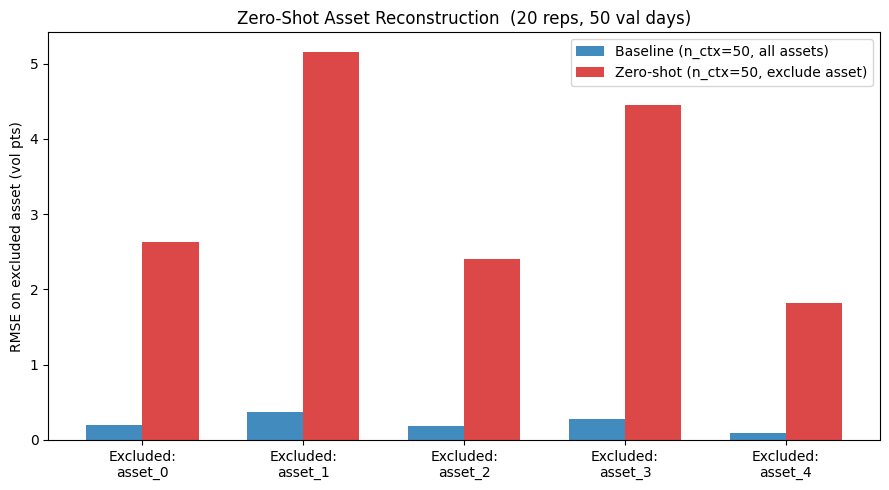


Zero-Shot vs Baseline RMSE (vol pts):
Asset           Baseline   Zero-shot     Ratio
asset_0           0.2004      2.6269     13.11x
asset_1           0.3657      5.1593     14.11x
asset_2           0.1789      2.4070     13.45x
asset_3           0.2800      4.4450     15.87x
asset_4           0.0953      1.8150     19.04x


In [49]:
# ── Zero-shot asset reconstruction ──────────────────────────────────────────

def make_batch_exclude_asset(feat, aids, day_idx, n_ctx, exclude_asset):
    """Context drawn from all assets EXCEPT exclude_asset."""
    B = len(day_idx)
    f = feat[day_idx]
    a = aids[day_idx]
    ctx_f = f[:, :N_CTX_POOL]
    ctx_a = a[:, :N_CTX_POOL]
    obs_feat_list, obs_aid_list = [], []
    for b in range(B):
        mask = (ctx_a[b] != exclude_asset).nonzero(as_tuple=False).squeeze(1)
        if len(mask) == 0:
            # fallback: use all points (shouldn't happen with 5 assets)
            mask = torch.arange(N_CTX_POOL, device=feat.device)
        if len(mask) >= n_ctx:
            perm = mask[torch.randperm(len(mask), device=feat.device)[:n_ctx]]
        else:
            reps = (n_ctx // len(mask)) + 1
            perm = mask.repeat(reps)[:n_ctx]
        obs_feat_list.append(ctx_f[b][perm])
        obs_aid_list.append(ctx_a[b][perm])
    obs_feat = torch.stack(obs_feat_list)
    obs_aid  = torch.stack(obs_aid_list)
    qry_feat = f[:, :, :2]
    qry_aid  = a
    target   = f[:, :, 2]
    return obs_feat, obs_aid, qry_feat, qry_aid, target


N_CTX_ZS       = 50
N_EVAL_DAYS_ZS = min(50, len(feat_val))
eval_days_zs   = torch.arange(N_EVAL_DAYS_ZS, device=device)
N_REPS_ZS      = 20
aid_tgt_zs     = aid_all[val_idx[:N_EVAL_DAYS_ZS], N_CTX_POOL:].astype(int)  # (B, N_TGT_POOL)

rmse_zeroshot  = np.zeros(N_ASSETS)   # zero-shot RMSE for each excluded asset
rmse_baseline  = np.zeros(N_ASSETS)   # normal RMSE on each asset (same n_ctx)

model.eval()
with torch.no_grad():
    for excl in range(N_ASSETS):
        sq_excl, sq_base = [], []
        for _ in range(N_REPS_ZS):
            # Zero-shot: exclude the asset
            of, oa, qf, qa, tgt = make_batch_exclude_asset(
                feat_val, aids_val, eval_days_zs, N_CTX_ZS, excl)
            pred = model(of, oa, qf, qa)
            pred_tgt = denorm_iv(pred[:, N_CTX_POOL:].cpu().numpy())
            true_tgt = denorm_iv(tgt[:, N_CTX_POOL:].cpu().numpy())
            err2 = (pred_tgt - true_tgt) ** 2
            mask_excl = aid_tgt_zs == excl
            sq_excl.append(err2[mask_excl].mean())

            # Baseline: all assets, same n_ctx
            of_b, oa_b, qf_b, qa_b, tgt_b = make_batch_asset_filtered(
                feat_val, aids_val, eval_days_zs, N_CTX_ZS, filter_asset=None)
            pred_b = model(of_b, oa_b, qf_b, qa_b)
            pred_tgt_b = denorm_iv(pred_b[:, N_CTX_POOL:].cpu().numpy())
            true_tgt_b = denorm_iv(tgt_b[:, N_CTX_POOL:].cpu().numpy())
            err2_b = (pred_tgt_b - true_tgt_b) ** 2
            sq_base.append(err2_b[mask_excl].mean())

        rmse_zeroshot[excl] = np.sqrt(np.mean(sq_excl)) * 100
        rmse_baseline[excl] = np.sqrt(np.mean(sq_base)) * 100

# Bar chart
fig, ax = plt.subplots(figsize=(9, 5))
x     = np.arange(N_ASSETS)
width = 0.35
ax.bar(x - width/2, rmse_baseline,  width, label=f'Baseline (n_ctx={N_CTX_ZS}, all assets)', color='C0', alpha=0.85)
ax.bar(x + width/2, rmse_zeroshot, width, label=f'Zero-shot (n_ctx={N_CTX_ZS}, exclude asset)', color='C3', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([f'Excluded:\n{ASSET_NAMES[a]}' for a in range(N_ASSETS)])
ax.set_ylabel('RMSE on excluded asset (vol pts)')
ax.set_title(f'Zero-Shot Asset Reconstruction  ({N_REPS_ZS} reps, {N_EVAL_DAYS_ZS} val days)')
ax.legend()
plt.tight_layout(); plt.show()

print("\nZero-Shot vs Baseline RMSE (vol pts):")
print(f"{'Asset':12s}  {'Baseline':>10s}  {'Zero-shot':>10s}  {'Ratio':>8s}")
for a in range(N_ASSETS):
    ratio = rmse_zeroshot[a] / max(rmse_baseline[a], 1e-8)
    print(f"{ASSET_NAMES[a]:12s}  {rmse_baseline[a]:10.4f}  {rmse_zeroshot[a]:10.4f}  {ratio:8.2f}x")

## Latent Space Analysis

We encode all validation days with the full context pool (n_ctx=400),
flatten to (N_val × N_ASSETS, D_LATENT) and project to 2D via PCA.

Subplots are coloured by all four stochastic Heston parameters:
θ (long-run variance), κ (mean-reversion speed), ξ (vol-of-vol), ρ (correlation).
Clear colour gradients along the principal components indicate that the
latent space has organised itself according to these parameters.

Latent codes: (500, 5, 32)
PC1 explains 58.0%,  PC2 explains 23.1% of variance


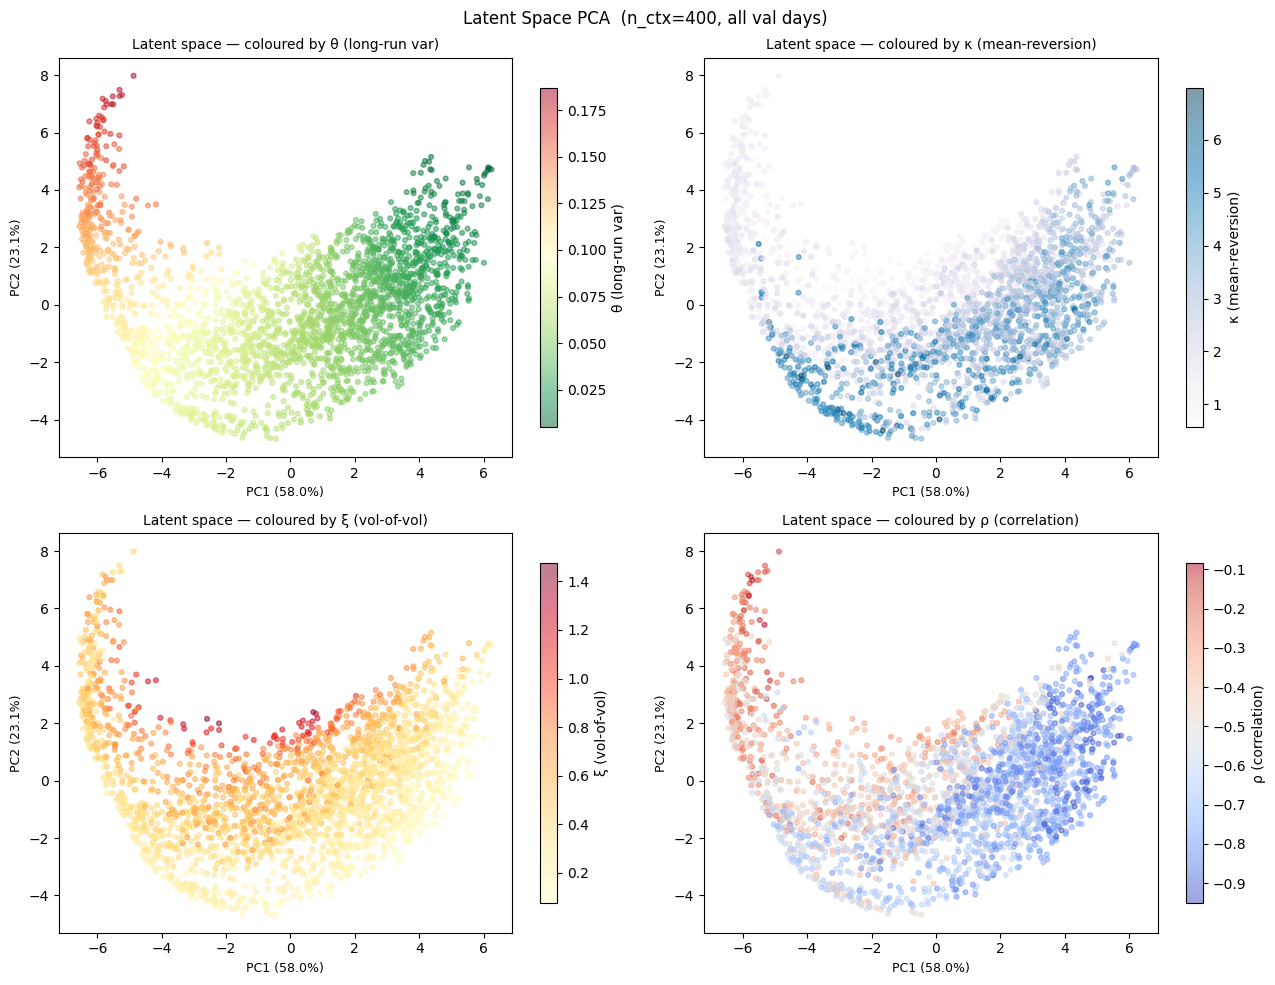

In [50]:
# ── Latent space PCA coloured by all 4 parameters ────────────────────────────
z_val = encode_days(feat_val, aids_val, n_ctx=400)
print(f"Latent codes: {z_val.shape}")

Z_flat = z_val.reshape(-1, D_LATENT)         # (N_val * N_ASSETS, D_LATENT)
Z_c    = Z_flat - Z_flat.mean(0)
_, S, Vt = np.linalg.svd(Z_c, full_matrices=False)
Z_2d   = Z_c @ Vt[:2].T                      # (N_val * N_ASSETS, 2)

# Variance explained
var_exp = S**2 / (S**2).sum()
print(f"PC1 explains {var_exp[0]*100:.1f}%,  PC2 explains {var_exp[1]*100:.1f}% of variance")

val_params = params[val_idx]   # (N_val, N_ASSETS, 5)  = [v0, kappa, theta, xi, rho]
# Flatten to (N_val * N_ASSETS,) for each parameter
v0_flat    = val_params[:, :, 0].reshape(-1)   # initial variance
kappa_flat = val_params[:, :, 1].reshape(-1)   # mean-reversion speed
theta_flat = val_params[:, :, 2].reshape(-1)   # long-run variance
xi_flat    = val_params[:, :, 3].reshape(-1)   # vol-of-vol
rho_flat   = val_params[:, :, 4].reshape(-1)   # correlation

param_list  = [theta_flat, kappa_flat, xi_flat, rho_flat]
param_names = ['θ (long-run var)', 'κ (mean-reversion)', 'ξ (vol-of-vol)', 'ρ (correlation)']
cmaps_list  = ['RdYlGn_r', 'PuBu', 'YlOrRd', 'coolwarm']

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes_flat = axes.ravel()

for idx, (param, pname, cmap_name) in enumerate(zip(param_list, param_names, cmaps_list)):
    ax = axes_flat[idx]
    sc = ax.scatter(Z_2d[:, 0], Z_2d[:, 1], c=param, cmap=cmap_name,
                    s=12, alpha=0.5, rasterized=True)
    plt.colorbar(sc, ax=ax, label=pname, shrink=0.85)
    ax.set_xlabel(f'PC1 ({var_exp[0]*100:.1f}%)', fontsize=9)
    ax.set_ylabel(f'PC2 ({var_exp[1]*100:.1f}%)', fontsize=9)
    ax.set_title(f'Latent space — coloured by {pname}', fontsize=10)

fig.suptitle('Latent Space PCA  (n_ctx=400, all val days)', fontsize=12)
plt.tight_layout(); plt.show()

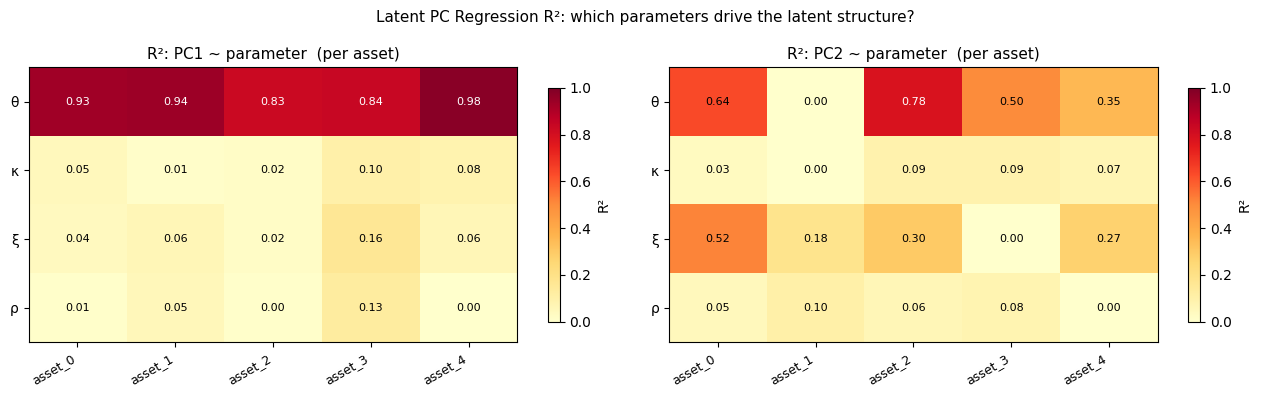


PC1 R² (param × asset):
        asset_0   asset_1   asset_2   asset_3   asset_4
θ         0.933     0.939     0.831     0.839     0.977
κ         0.046     0.009     0.019     0.098     0.084
ξ         0.037     0.060     0.018     0.158     0.061
ρ         0.007     0.054     0.004     0.129     0.001


In [51]:
# ── PC1 / PC2 ~ parameter R² heatmap ────────────────────────────────────────
from numpy.linalg import lstsq

# PC scores per (day, asset) point
# Z_2d is already (N_val * N_ASSETS, 2)
# val_params is (N_val, N_ASSETS, 5)

param_arrays = {
    'θ': val_params[:, :, 2],   # (N_val, N_ASSETS)
    'κ': val_params[:, :, 1],
    'ξ': val_params[:, :, 3],
    'ρ': val_params[:, :, 4],
}

# R² for PC1 and PC2 separately
# Dimensions: params × assets
param_names_short = list(param_arrays.keys())
R2_pc1 = np.zeros((len(param_arrays), N_ASSETS))
R2_pc2 = np.zeros((len(param_arrays), N_ASSETS))

for p_idx, (pname, p_arr) in enumerate(param_arrays.items()):
    for a in range(N_ASSETS):
        # Extract PC scores for asset a across all val days
        # In Z_2d, point (day * N_ASSETS + a) corresponds to (day, a)
        asset_indices = np.arange(len(val_idx)) * N_ASSETS + a
        pc_scores = Z_2d[asset_indices, :]   # (N_val, 2)
        param_vals = p_arr[:, a]             # (N_val,)

        # OLS: PC ~ param (with intercept)
        X = np.column_stack([np.ones(len(param_vals)), param_vals])
        for pc_idx, pc_col in enumerate([0, 1]):
            y = pc_scores[:, pc_col]
            coeffs, _, _, _ = lstsq(X, y, rcond=None)
            y_hat = X @ coeffs
            ss_res = np.sum((y - y_hat)**2)
            ss_tot = np.sum((y - y.mean())**2)
            r2 = 1.0 - ss_res / (ss_tot + 1e-12)
            if pc_col == 0:
                R2_pc1[p_idx, a] = max(r2, 0.0)
            else:
                R2_pc2[p_idx, a] = max(r2, 0.0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, R2, pc_label in zip(axes, [R2_pc1, R2_pc2], ['PC1', 'PC2']):
    im = ax.imshow(R2, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
    ax.set_xticks(range(N_ASSETS))
    ax.set_xticklabels(ASSET_NAMES, rotation=30, ha='right', fontsize=9)
    ax.set_yticks(range(len(param_names_short)))
    ax.set_yticklabels(param_names_short, fontsize=10)
    ax.set_title(f'R²: {pc_label} ~ parameter  (per asset)', fontsize=11)
    plt.colorbar(im, ax=ax, label='R²', shrink=0.85)
    for i in range(len(param_names_short)):
        for j in range(N_ASSETS):
            ax.text(j, i, f'{R2[i,j]:.2f}', ha='center', va='center',
                    fontsize=8, color='black' if R2[i,j] < 0.7 else 'white')

fig.suptitle('Latent PC Regression R²: which parameters drive the latent structure?', fontsize=11)
plt.tight_layout(); plt.show()

print("\nPC1 R² (param × asset):")
print(f"{'':5s}  " + '  '.join(f'{n:>8s}' for n in ASSET_NAMES))
for i, pname in enumerate(param_names_short):
    print(f"{pname:5s}  " + '  '.join(f'{R2_pc1[i,a]:8.3f}' for a in range(N_ASSETS)))

## Cross-Asset Latent Interpolation

Fix the latent codes of 4 assets and interpolate asset_0's code between
two extreme days (one with low v0, one with high v0).
If the architecture is well-behaved, only asset_0's surface should change
as α moves from 0 to 1.

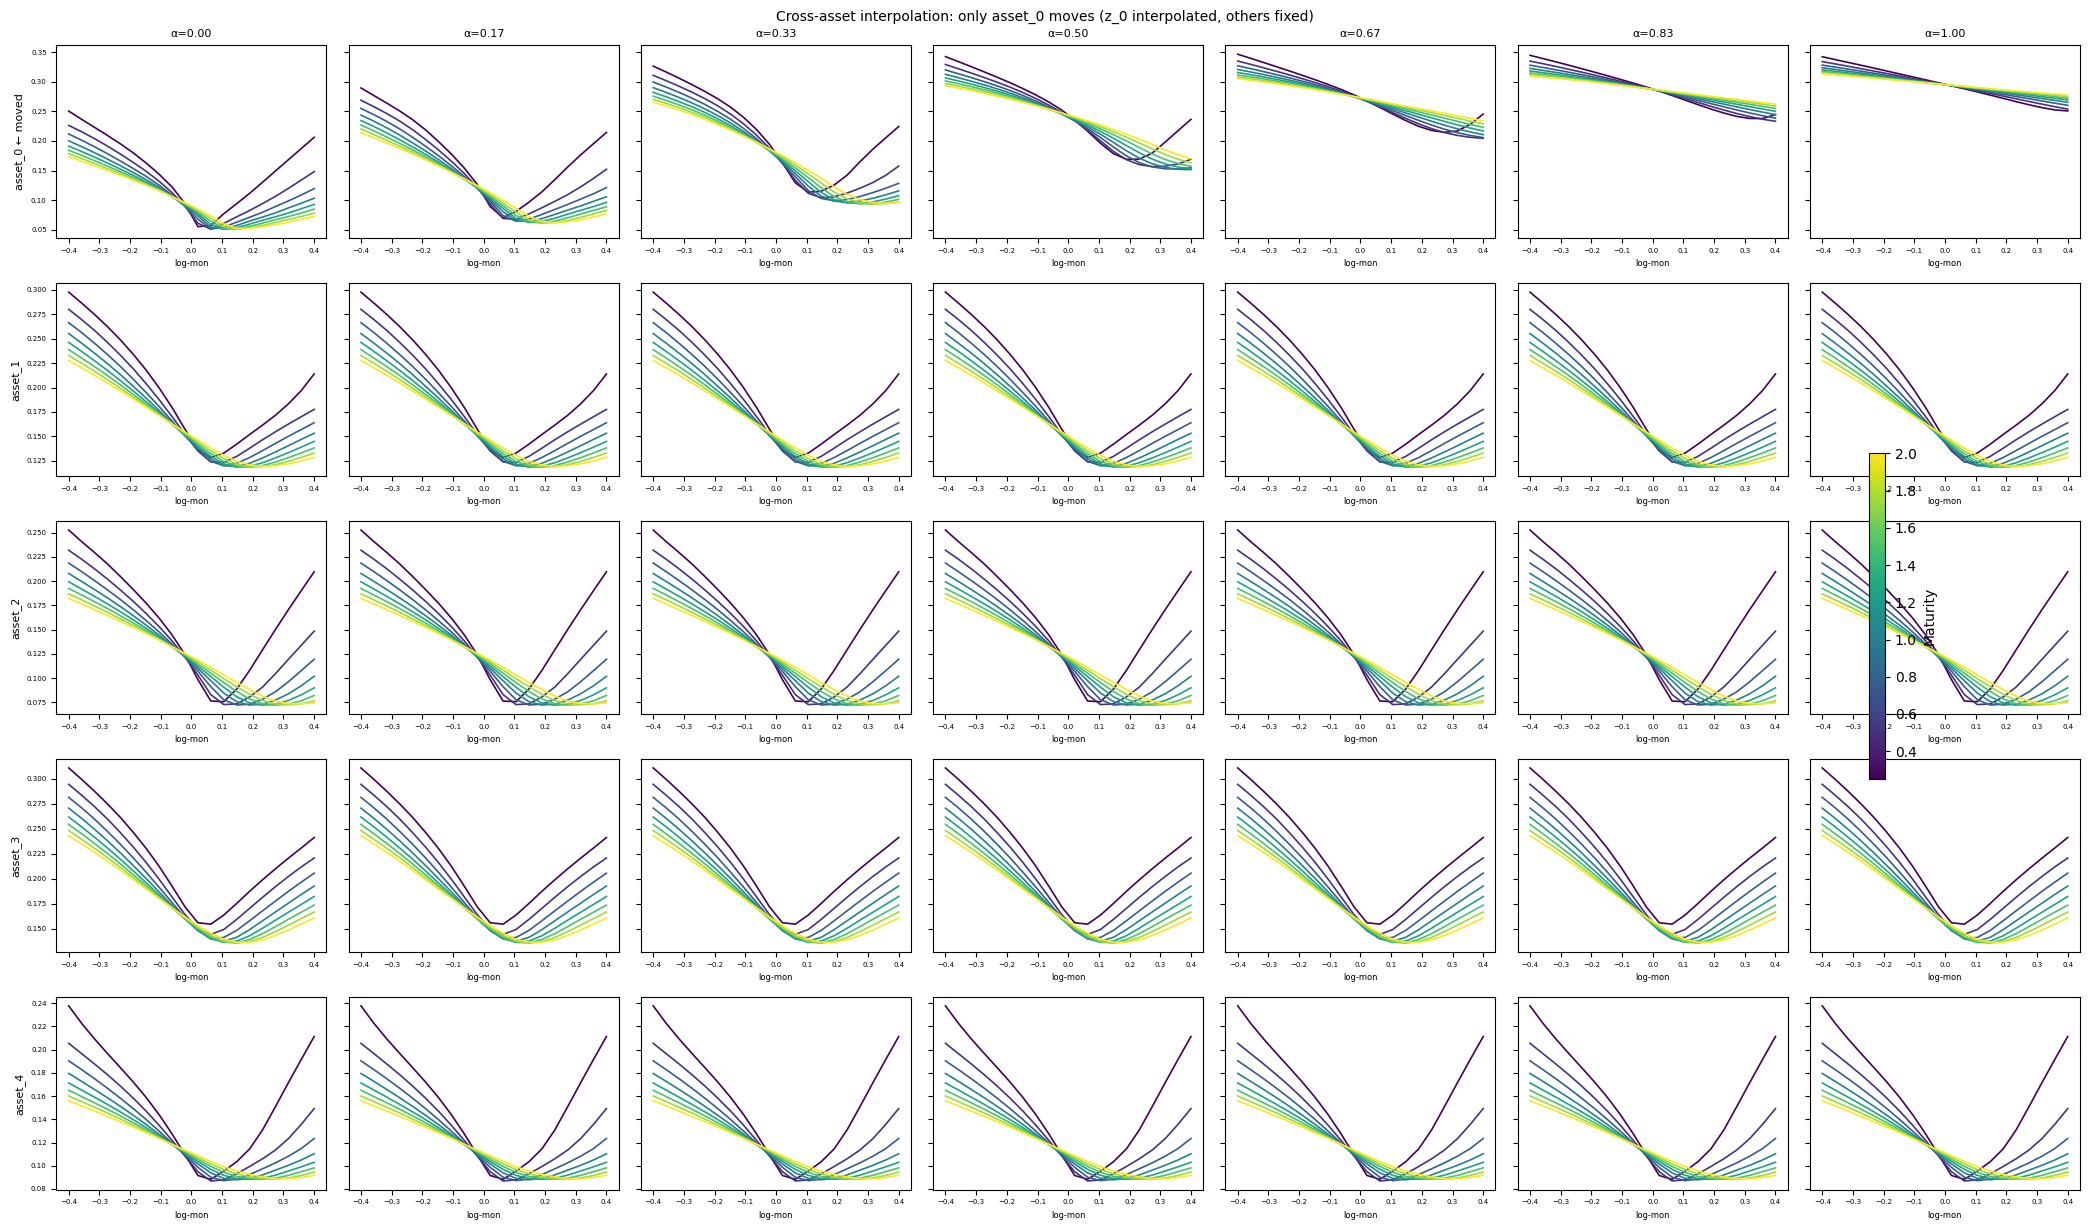

In [52]:
# Pick two val days that differ strongly in v0 for asset 0
v0_asset0 = params[val_idx, 0, 0]
day_lo = val_idx[np.argmin(v0_asset0)]
day_hi = val_idx[np.argmax(v0_asset0)]

z_lo = torch.from_numpy(encode_days(feat_t[[day_lo]], aids_t[[day_lo]])[0]).float().to(device)
z_hi = torch.from_numpy(encode_days(feat_t[[day_hi]], aids_t[[day_hi]])[0]).float().to(device)

MOVE_ASSET = 0
N_INTERP   = 7
alphas     = np.linspace(0, 1, N_INTERP)

model.eval()
fig, axes = plt.subplots(N_ASSETS, N_INTERP,
                          figsize=(3*N_INTERP, 2.5*N_ASSETS), sharey='row')
cmap = plt.cm.viridis
cols = [cmap(i / (N_VIS_MATS - 1)) for i in range(N_VIS_MATS)]

with torch.no_grad():
    for j, alpha in enumerate(alphas):
        z_interp = z_lo.clone().unsqueeze(0)   # (1, N_ASSETS, d_latent)
        z_interp[0, MOVE_ASSET] = (1-alpha)*z_lo[MOVE_ASSET] + alpha*z_hi[MOVE_ASSET]

        for a in range(N_ASSETS):
            ax = axes[a, j]
            qry_aid = torch.full((1, N_VIS_GRID), a, dtype=torch.long, device=device)
            pred_n  = model.decode(z_interp, vis_grid_t, qry_aid).cpu().numpy()[0]
            pred_iv = denorm_iv(pred_n)

            for t_idx in range(N_VIS_MATS):
                sl = slice(t_idx * N_VIS_LM, (t_idx + 1) * N_VIS_LM)
                ax.plot(VIS_LM, pred_iv[sl], color=cols[t_idx], lw=1.2)
            if a == 0:
                ax.set_title(f'α={alpha:.2f}', fontsize=8)
            if j == 0:
                mover = ' ← moved' if a == MOVE_ASSET else ''
                ax.set_ylabel(f'{ASSET_NAMES[a]}{mover}', fontsize=8)
            ax.set_xlabel('log-mon', fontsize=6)
            ax.tick_params(labelsize=5)

fig.suptitle(
    f'Cross-asset interpolation: only {ASSET_NAMES[MOVE_ASSET]} moves '
    f'(z_{MOVE_ASSET} interpolated, others fixed)', fontsize=10)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0.25, 2.0))
fig.colorbar(sm, ax=axes, label='Maturity', fraction=0.01)
plt.tight_layout(); plt.show()

## OOD Generalization Test

We load `heston_multiasset_ood_test.npz` — generated by notebook 01 with an
independent OU seed, so its parameter trajectories are entirely different from
the training/val OU path.

**No fine-tuning**: we run the trained model directly on the OOD set.

We compare RMSE vs context size for val and OOD on the same axes.
- If curves nearly overlap → the model learned genuine structural properties of Heston surfaces
- If OOD RMSE is much higher → the model partially memorised OU autocorrelation patterns

OOD days: 200, points/day: 800
n_ctx=   5  val RMSE=0.29102  OOD RMSE=0.28803  ratio=0.99x
n_ctx=  20  val RMSE=0.09508  OOD RMSE=0.08917  ratio=0.94x
n_ctx=  50  val RMSE=0.05842  OOD RMSE=0.04514  ratio=0.77x
n_ctx= 100  val RMSE=0.05466  OOD RMSE=0.04225  ratio=0.77x
n_ctx= 200  val RMSE=0.05370  OOD RMSE=0.04151  ratio=0.77x


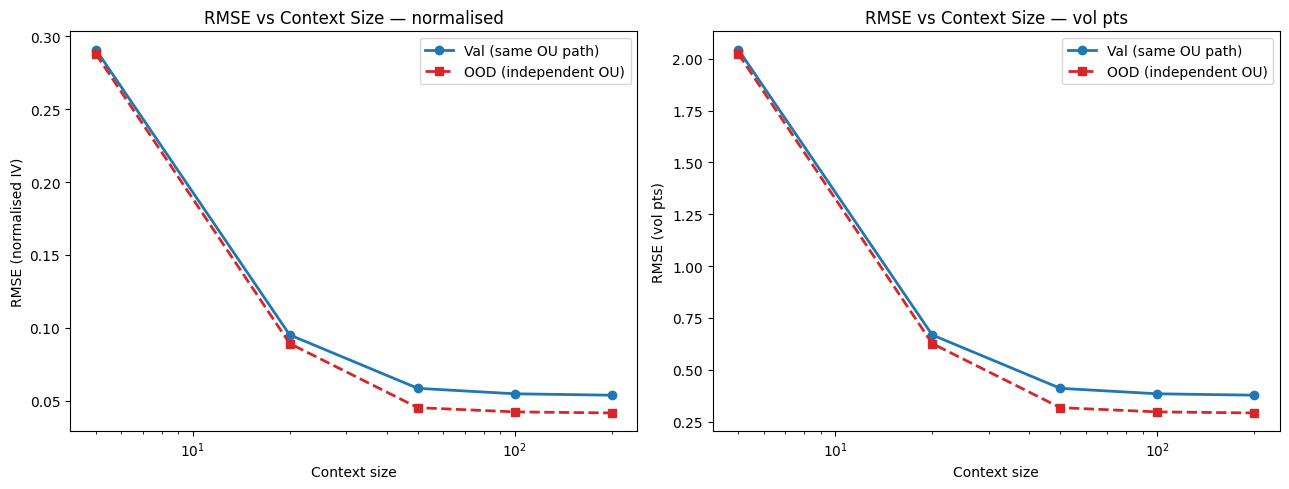


OOD / Val RMSE ratio at n_ctx=200: 0.77x
Ratio close to 1.0 → genuine generalization; ratio >> 1.0 → partial memorisation of OU structure.


In [53]:
# ── OOD Generalization Test ──────────────────────────────────────────────────
import os

OOD_PATH = '../Data/heston_multiasset_ood_test.npz'

if not os.path.exists(OOD_PATH):
    print(f"OOD file not found at {OOD_PATH}")
    print("Please run notebook 01 with an independent OU seed to generate it.")
    print("Skipping OOD evaluation.")
else:
    data_ood = np.load(OOD_PATH)

    lm_ood  = data_ood['lm']
    T_ood   = data_ood['maturity']
    aid_ood = data_ood['asset_id']
    iv_ood  = data_ood['iv']
    # OOD file has no 'split' key — all rows are test
    N_DAYS_OOD = lm_ood.shape[0]

    print(f"OOD days: {N_DAYS_OOD}, points/day: {lm_ood.shape[1]}")
    assert lm_ood.shape[1] == N_TOTAL, (
        f"OOD N_TOTAL={lm_ood.shape[1]} != training N_TOTAL={N_TOTAL}")

    # Normalise OOD with TRAINING norm stats (do NOT refit)
    feat_ood_raw  = np.stack([lm_ood, T_ood, iv_ood], axis=-1).astype(np.float32)
    feat_ood_norm = (feat_ood_raw - norm_mean) / norm_std   # use training norm

    feat_ood_t = torch.from_numpy(feat_ood_norm).to(device)
    aids_ood_t = torch.from_numpy(aid_ood.astype(np.int64)).to(device)

    CTX_SIZES_OOD = [5, 20, 50, 100, 200]
    N_REPS_OOD    = 10

    val_rmse_vs_ctx = []
    ood_rmse_vs_ctx = []

    model.eval()
    for nc in CTX_SIZES_OOD:
        # Val RMSE
        vr_sum = 0.0
        or_sum = 0.0
        for _ in range(N_REPS_OOD):
            # Val
            of, oa, qf, qa, tgt = make_batch(
                feat_val, aids_val, torch.arange(len(feat_val), device=device), nc)
            with torch.no_grad():
                pred = model(of, oa, qf, qa)
            pred_tgt = pred[:, N_CTX_POOL:]
            tgt_tgt  = tgt[:, N_CTX_POOL:]
            vr_sum  += F.mse_loss(pred_tgt, tgt_tgt).sqrt().item()

            # OOD
            of_o, oa_o, qf_o, qa_o, tgt_o = make_batch(
                feat_ood_t, aids_ood_t, torch.arange(len(feat_ood_t), device=device), nc)
            with torch.no_grad():
                pred_o = model(of_o, oa_o, qf_o, qa_o)
            pred_tgt_o = pred_o[:, N_CTX_POOL:]
            tgt_tgt_o  = tgt_o[:, N_CTX_POOL:]
            or_sum    += F.mse_loss(pred_tgt_o, tgt_tgt_o).sqrt().item()

        val_rmse_vs_ctx.append(vr_sum / N_REPS_OOD)
        ood_rmse_vs_ctx.append(or_sum / N_REPS_OOD)
        print(f"n_ctx={nc:4d}  val RMSE={val_rmse_vs_ctx[-1]:.5f}  "
              f"OOD RMSE={ood_rmse_vs_ctx[-1]:.5f}  "
              f"ratio={ood_rmse_vs_ctx[-1]/max(val_rmse_vs_ctx[-1],1e-8):.2f}x")

    # Convert to vol pts
    val_rmse_vp = [r * norm_std[2] * 100 for r in val_rmse_vs_ctx]
    ood_rmse_vp = [r * norm_std[2] * 100 for r in ood_rmse_vs_ctx]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    ax = axes[0]
    ax.plot(CTX_SIZES_OOD, val_rmse_vs_ctx, 'o-', color='C0', label='Val (same OU path)', lw=2)
    ax.plot(CTX_SIZES_OOD, ood_rmse_vs_ctx, 's--', color='C3', label='OOD (independent OU)', lw=2)
    ax.set_xlabel('Context size'); ax.set_ylabel('RMSE (normalised IV)')
    ax.set_title('RMSE vs Context Size — normalised'); ax.legend(); ax.set_xscale('log')

    ax = axes[1]
    ax.plot(CTX_SIZES_OOD, val_rmse_vp, 'o-', color='C0', label='Val (same OU path)', lw=2)
    ax.plot(CTX_SIZES_OOD, ood_rmse_vp, 's--', color='C3', label='OOD (independent OU)', lw=2)
    ax.set_xlabel('Context size'); ax.set_ylabel('RMSE (vol pts)')
    ax.set_title('RMSE vs Context Size — vol pts'); ax.legend(); ax.set_xscale('log')

    plt.tight_layout(); plt.show()

    print(f"\nOOD / Val RMSE ratio at n_ctx={CTX_SIZES_OOD[-1]}: "
          f"{ood_rmse_vs_ctx[-1]/max(val_rmse_vs_ctx[-1],1e-8):.2f}x")
    print("Ratio close to 1.0 → genuine generalization; "
          "ratio >> 1.0 → partial memorisation of OU structure.")